In [64]:
# ==============================
# CUSTOMER CHURN PREDICTION 
# ==============================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report, roc_curve, roc_auc_score,auc
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

In [65]:
# ==============================
# 2. LOAD DATA
# ==============================

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head(20)
df.info()
df.describe()
df['Churn'].value_counts()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [66]:
# ==============================
# 3. DATA PREPROCESSING
# ==============================
df = df.dropna()

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])



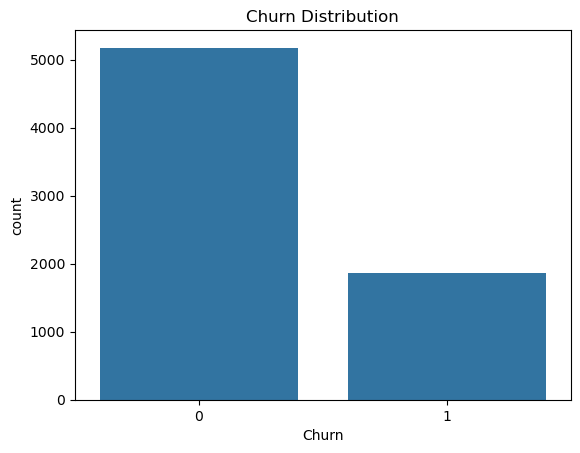

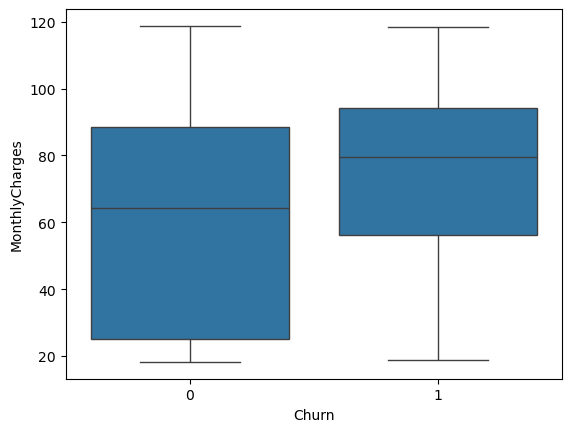

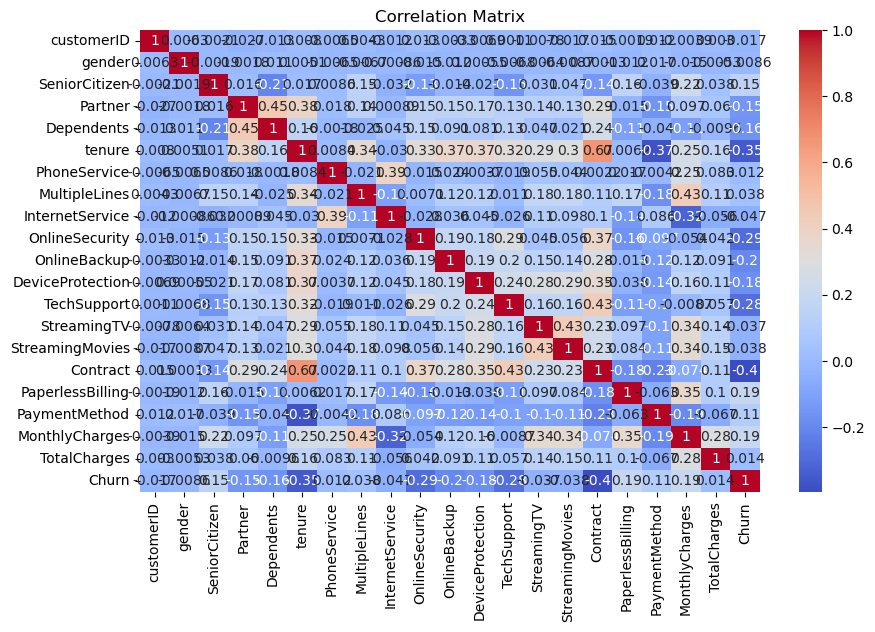

In [67]:
# ==============================
# 4. EDA (USING plt)
# ==============================

# Churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Monthly charges vs churn
if 'MonthlyCharges' in df.columns:
    sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
    plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [68]:
# ==============================
# 5. DATA CLEANING
# ==============================
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)

In [69]:
# ==============================
# 6. ENCODING
# ==============================
df = pd.get_dummies(df, drop_first=True)

In [70]:
# 7. FIX TARGET COLUMN
target_col = [col for col in df.columns if 'Churn' in col][0]

X = df.drop(target_col, axis=1)
y = df[target_col]

In [71]:
# ==============================
# 8. TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [72]:
# ==============================
# 9. SCALING (for KNN, SVM)
# ==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [73]:
# ==============================
# 10. MODEL TRAINING + COMPARISON
# ==============================
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

results = []

for name, model in models.items():
    if name in ["KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        acc = model.score(X_test_scaled, y_test)
    else:
        model.fit(X_train, y_train)
        acc = model.score(X_test, y_test)

    results.append([name, acc])
    print(f"{name} Accuracy: {acc}")

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Accuracy: 0.8147622427253371
Decision Tree Accuracy: 0.7331440738112136
Random Forest Accuracy: 0.7920511000709723
KNN Accuracy: 0.7735982966643009
SVM Accuracy: 0.8069552874378992


In [74]:
# ==============================
# 11. RESULT TABLE
# ==============================
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\nModel Comparison:\n", results_df)



Model Comparison:
            Model  Accuracy
0       Logistic  0.814762
1  Decision Tree  0.733144
2  Random Forest  0.792051
3            KNN  0.773598
4            SVM  0.806955


In [75]:
# ==============================
# 12. BEST MODEL (Random Forest)
# ==============================
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [76]:
# 13. DEFINE PIPELINE
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(solver='liblinear'))
])

In [77]:
# ==============================
# 14. GRID SEARCH (TUNING)
# ==============================
param_grid = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [1,2,3,4,5,6,10],
    'model__max_iter': [100,200,300]
}

grid = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)



Best Parameters: {'model__C': 1, 'model__max_iter': 100, 'model__penalty': 'l1'}
Best CV Score: 0.8012064598794959


In [78]:
# ==============================
# 15. FINAL PREDICTION
# ==============================
y_pred = grid.predict(X_test)


In [79]:
# ==============================
# 16. EVALUATION
# ==============================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.8176011355571328

Confusion Matrix:
 [[940  96]
 [161 212]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



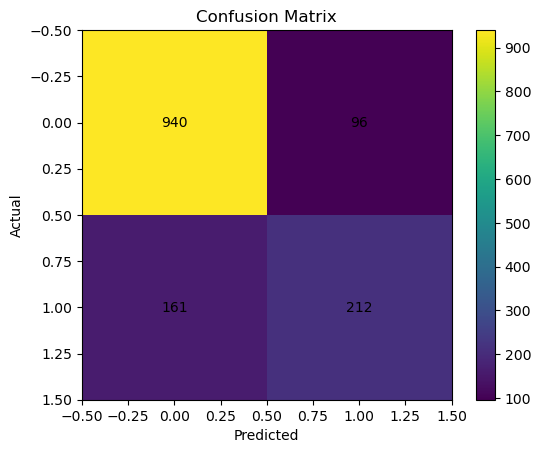

In [80]:
# ==============================
# 17. CONFUSION MATRIX PLOT
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

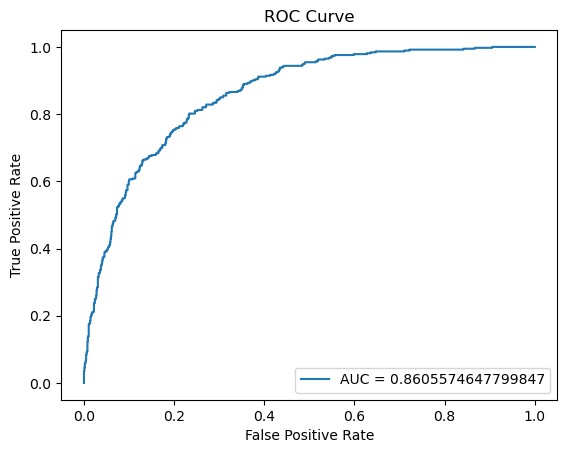

AUC Score: 0.8605574647799847


In [81]:
# ==============================
# 18. ROC CURVE
# ==============================
y_prob = grid.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr,label=f"AUC = {roc_auc}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))


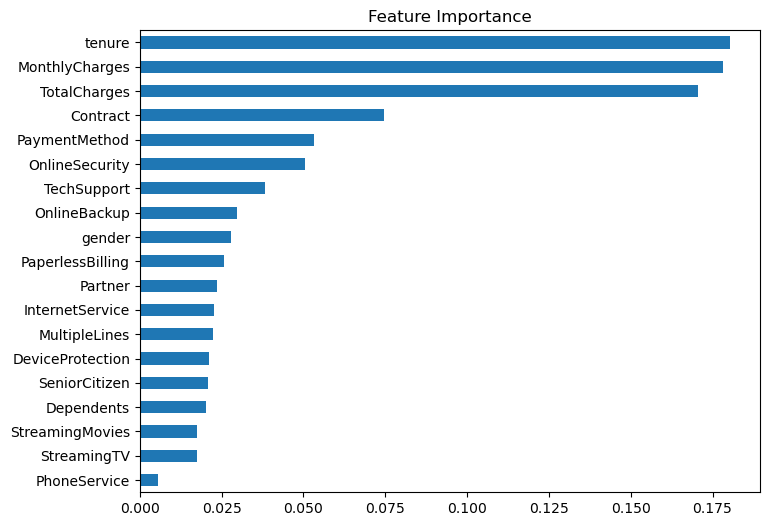

In [82]:
# ==============================
# 19. FEATURE IMPORTANCE
# ==============================
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()


In [83]:
# ==============================
# 20. HYPERPARAMETER TUNING
# ==============================
params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)



Best Parameters: {'max_depth': 10, 'n_estimators': 100}


In [84]:
# ==============================
# 21. FINAL MODEL
# ==============================
best_model = grid.best_estimator_

y_pred_final = best_model.predict(X_test)

print("\nFinal Model Report:\n", classification_report(y_test, y_pred_final)) 

# ==============================
# END PROJECT
# ==============================


Final Model Report:
               precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

